In [41]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

In [42]:
df = pd.read_csv('..\\..\\created_data\\segments\\kd_sg2_q_age.csv', header=0, 
                 names=['lat', 'lon', 'q', 'age'])
print(df.head())

       lat     lon      q       age
0  48.7500 -127.75  200.0  2.906279
1  47.8983 -127.20  161.0  4.359262
2  47.8983 -127.65  304.0  3.190760
3  48.6833 -126.87   60.8  5.543758
4  48.6850 -126.87   63.7  5.543758


now for pars-scl, we get depth from formula 21 and heat flow from formula 23... and for stein x2 we get depth and heat flow from pg 126

In [43]:
ihfc_qt = []
sqrt_age = []
ps_qt = []
dt_ps = []
stein_qt = []
dt_stein = []

# ihfc
for q in df['q']:
    ihfc_qt.append(q*0.0238846)  # mW/m^2 --> μcal/cm^2*s

# pars-scl
for a in df['age']:
    sqrt_age.append(a**(0.5))
    dt_ps.append(2500 + 350*(a**(0.5)))
    ps_qt.append(11.3/a**(0.5))

# stein x2
for a in df['age']:
    dt_stein.append(2600 + 365*(a**0.5))
    stein_qt.append((510/a**(0.5))*0.0239)  # mW/m^2 --> μcal/cm^2*s

print(f'pars-scl depth: {dt_ps[0:11]}\nstein depth: {dt_stein[0:11]}')
# print(f'sqrt(age): {sqrt_age[:2]}')
# print(f'ihfc heat flow: {ihfc_qt[:2]}, pars-scl heat flow: {ps_qt[:2]}, stein heat flow: {stein_qt[:2]}')

pars-scl depth: [3096.6734364373865, 3230.7596013738034, 3125.1944595483874, 3324.0815146270425, 3324.0815146270425, 3324.0815146270425, 3324.0815146270425, 3324.0815146270425, 3324.0815146270425, 3324.0815146270425, 3324.0815146270425]
stein depth: [3222.245155141846, 3362.077870004109, 3251.9885078147468, 3459.399293825344, 3459.399293825344, 3459.399293825344, 3459.399293825344, 3459.399293825344, 3459.399293825344, 3459.399293825344, 3459.399293825344]


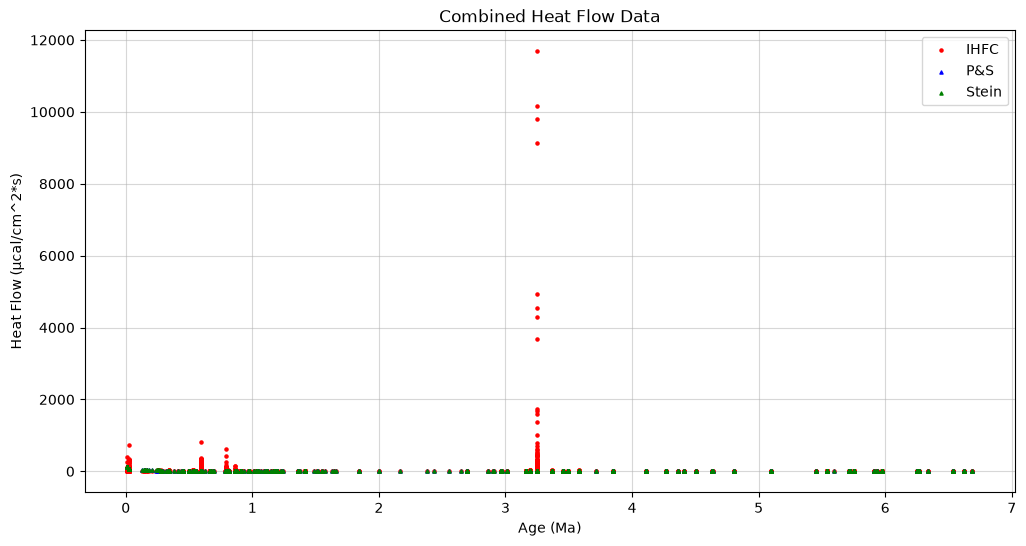

In [44]:
fig0, ax0 = plt.subplots(figsize=(12, 6))

ax0.scatter(df['age'], ihfc_qt, marker='o',color='red', s=5, label='IHFC')
ax0.scatter(df['age'], ps_qt, marker='^', color='blue', s=5, label='P&S')
ax0.scatter(df['age'], stein_qt, marker='^', color='green', s=5, label='Stein')
# ax0.set_ylim(0, 120)
ax0.set_xlabel('Age (Ma)')
ax0.set_ylabel('Heat Flow (μcal/cm^2*s)')
ax0.set_title('Combined Heat Flow Data')
ax0.set_axisbelow(True)

plt.grid(alpha=0.5)
plt.legend()
plt.show()

# tesseroid time!
Now we are going to plot the gravity as a tesseroid (6 bounds: west, east, south, north, bottom, top)

In [45]:
import boule as bl
import verde as vd
import harmonica as hm
from numba import njit

In [46]:
ellipsoid = bl.WGS84
mean_radius = ellipsoid.mean_radius  # from boule, earth radius

top = mean_radius - dt_ps  # places the top of the tesseroid at the predicted pars-scl seafloor depth
thickness = 7000  # assuming oceanic crust is 7km aka cmb
cmb = top - thickness
bottom = mean_radius - dt_ps - thickness  # places the bottom of the tesseroid at predicted pars-scl seafloor depth

region=df['lon'].min(), df['lon'].max(), df['lat'].min(), df['lat'].max()
spacing=0.005  # number of pnts in each S-N and W-E direction, adjust based on data density

In [47]:
block_reduce = pygmt.blockmedian(x=df['lon'], y=df['lat'], z=dt_ps,   # or whatever column you want gridded
    region=region,
    spacing=spacing)

# interpolate onto a continuous grid
ps_depth_grid = pygmt.surface(data=block_reduce, region=region, spacing=spacing)

print(ps_depth_grid.head())

block_reduce = pygmt.blockmedian(x=df['lon'], y=df['lat'], z=dt_stein,   # or whatever column you want gridded
    region=region,
    spacing=spacing)

# interpolate onto a continuous grid
stein_depth_grid = pygmt.surface(data=block_reduce, region=region, spacing=spacing)

print(stein_depth_grid.head())

blockmedian [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
blockmedian [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
blockmedian (gmtapi_init_grdheader): Please select compatible -R and -I values
surface [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
surface [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
surface (gmtapi_init_grdheader): Please select compatible -R and -I values
surface [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
surface [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
surface (gmtapi_init_grdheader): Please select compatible -R and -I values
blockmedian [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.00

<xarray.DataArray 'z' (y: 5, x: 5)> Size: 100B
array([[2675.6897, 2673.8489, 2671.9924, 2670.1204, 2668.2322],
       [2678.34  , 2676.504 , 2674.6516, 2672.7832, 2670.8982],
       [2680.9924, 2679.1606, 2677.3127, 2675.4482, 2673.5667],
       [2683.647 , 2681.82  , 2679.9766, 2678.116 , 2676.238 ],
       [2686.304 , 2684.4822, 2682.643 , 2680.7869, 2678.9126]],
      dtype=float32)
Coordinates:
  * y        (y) float64 40B 47.69 47.69 47.7 47.7 47.71
  * x        (x) float64 40B -129.5 -129.5 -129.5 -129.5 -129.5
Attributes:
    Conventions:   CF-1.7
    title:         Data gridded with continuous surface splines in tension
    history:       gmt surface @GMTAPI@-S-I-D-V-T-N-000000 -G@GMTAPI@-S-O-G-G...
    description:   
    actual_range:  [nan nan]
    long_name:     z
<xarray.DataArray 'z' (y: 5, x: 5)> Size: 100B
array([[2783.219 , 2781.2993, 2779.3635, 2777.4111, 2775.442 ],
       [2785.9832, 2784.068 , 2782.1365, 2780.188 , 2778.2222],
       [2788.749 , 2786.8389, 2784.911

0.005 is good spacing, looks similar to 0.01 but has better reso, 0.001 makes too much stuff up

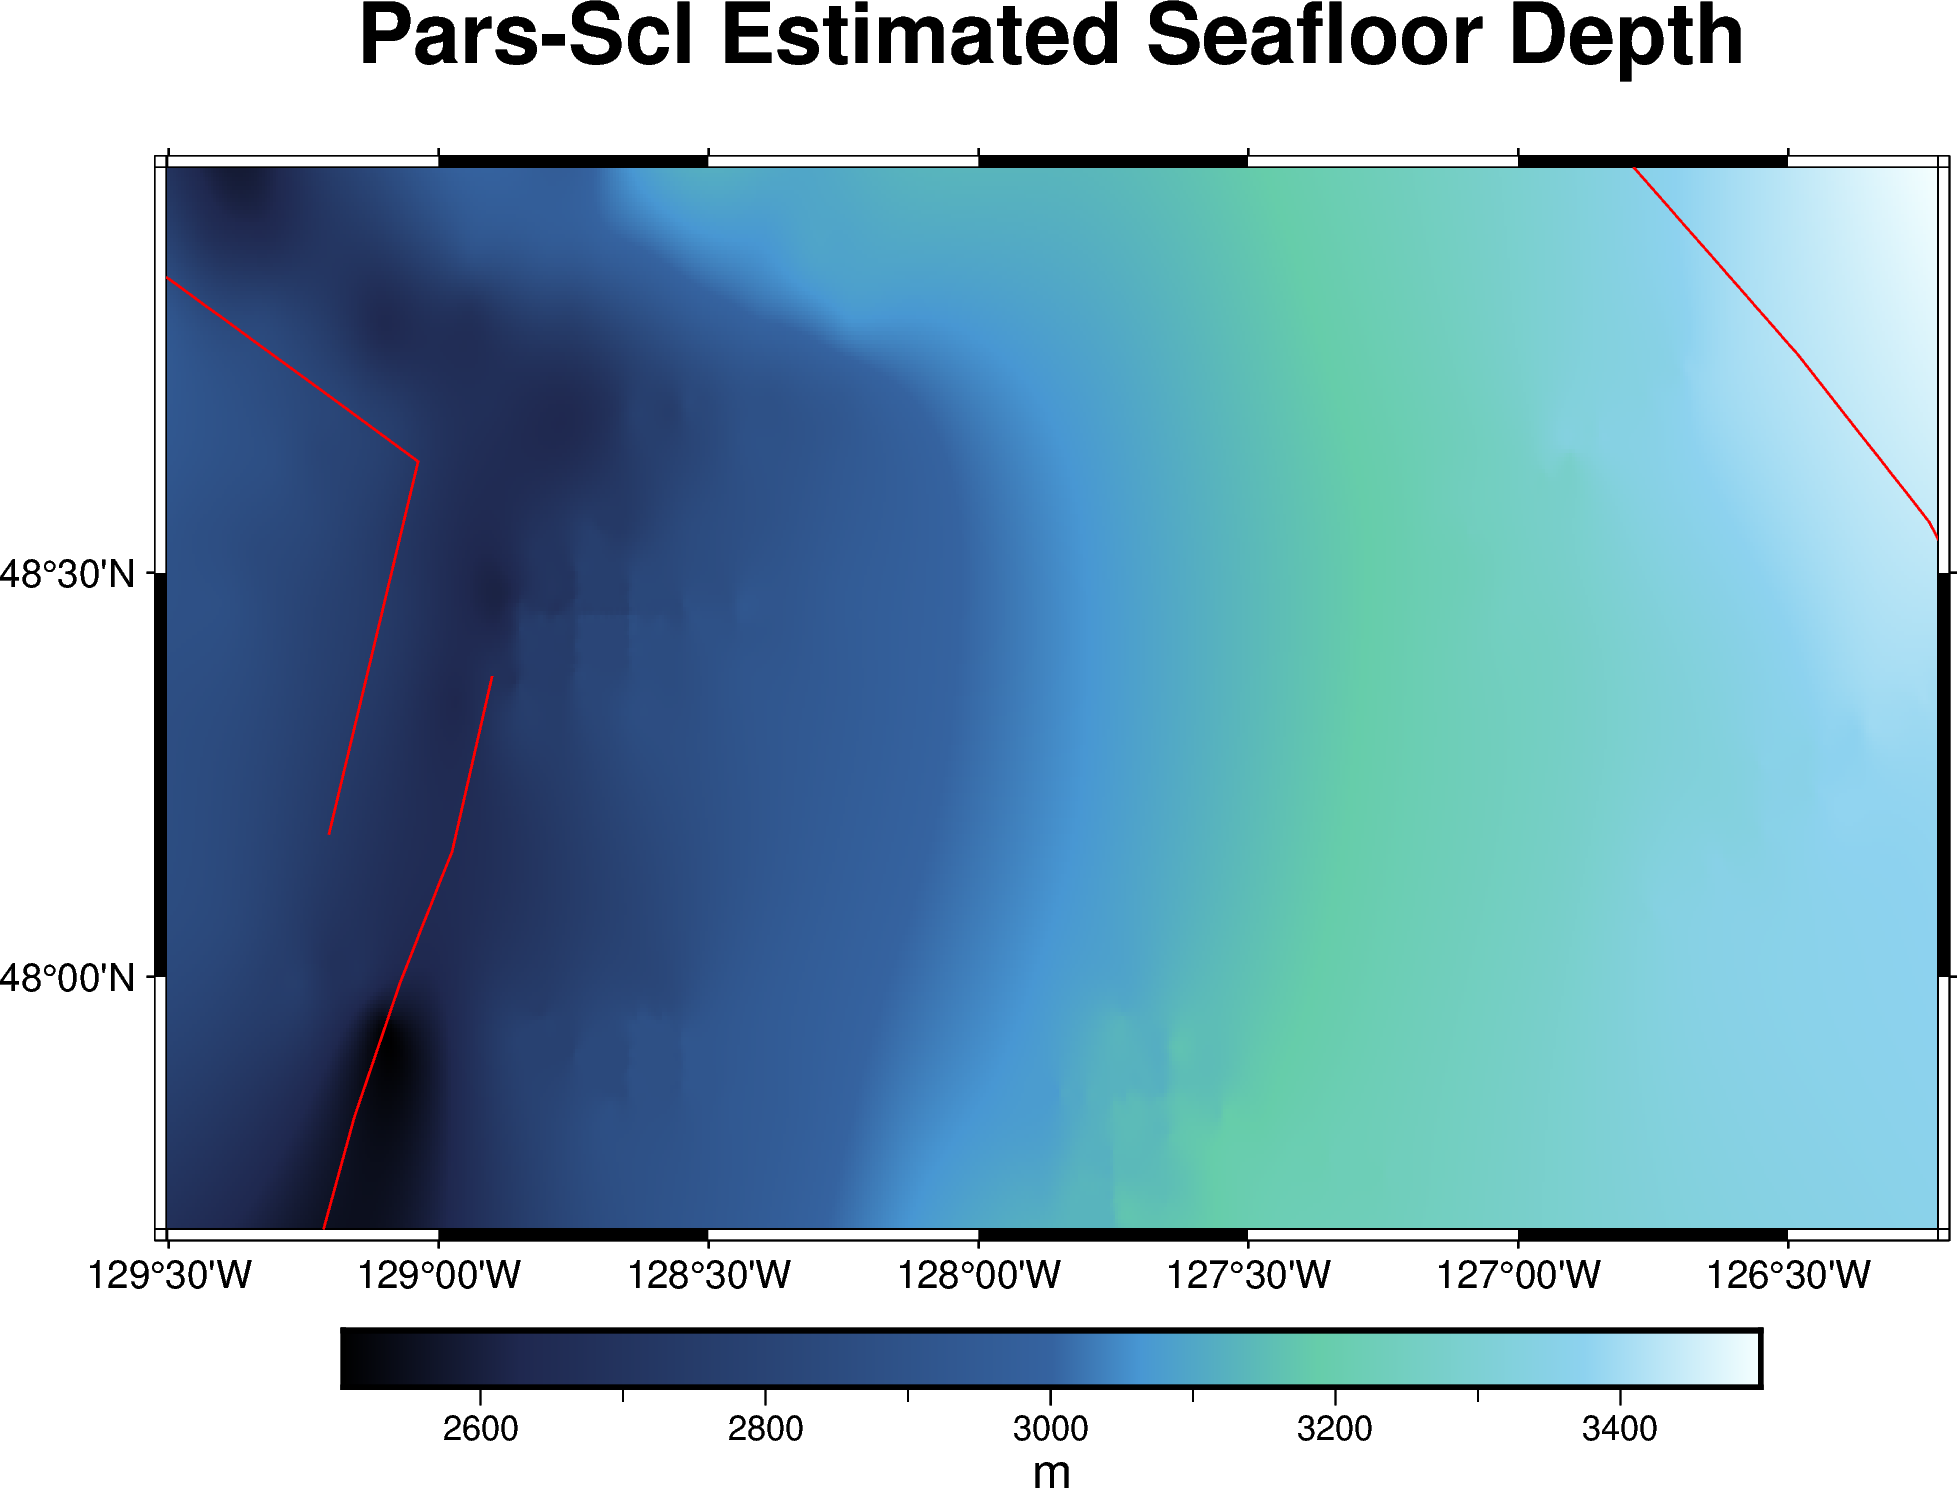

In [ ]:
fig2 = pygmt.Figure()
title = 'Pars-Scl Estimated Seafloor Depth'

pygmt.makecpt(cmap='bathy', series=[ps_depth_grid.min().values, ps_depth_grid.max().values])

fig2.grdimage(grid=ps_depth_grid, cmap=True, region=region, projection='M15c', frame=['a', f'+t{title}'])
fig2.colorbar(cmap=True, frame=['a200f100', 'x+lm'])  # annotate every x, tick every y
fig2.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.5p,red')
fig2.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')

fig2.savefig('..\\..\\figures\\seg2\\depth_ps_0.005.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig2.show()

[gradient](https://www.pygmt.org/dev/gallery/images/grdgradient.html)

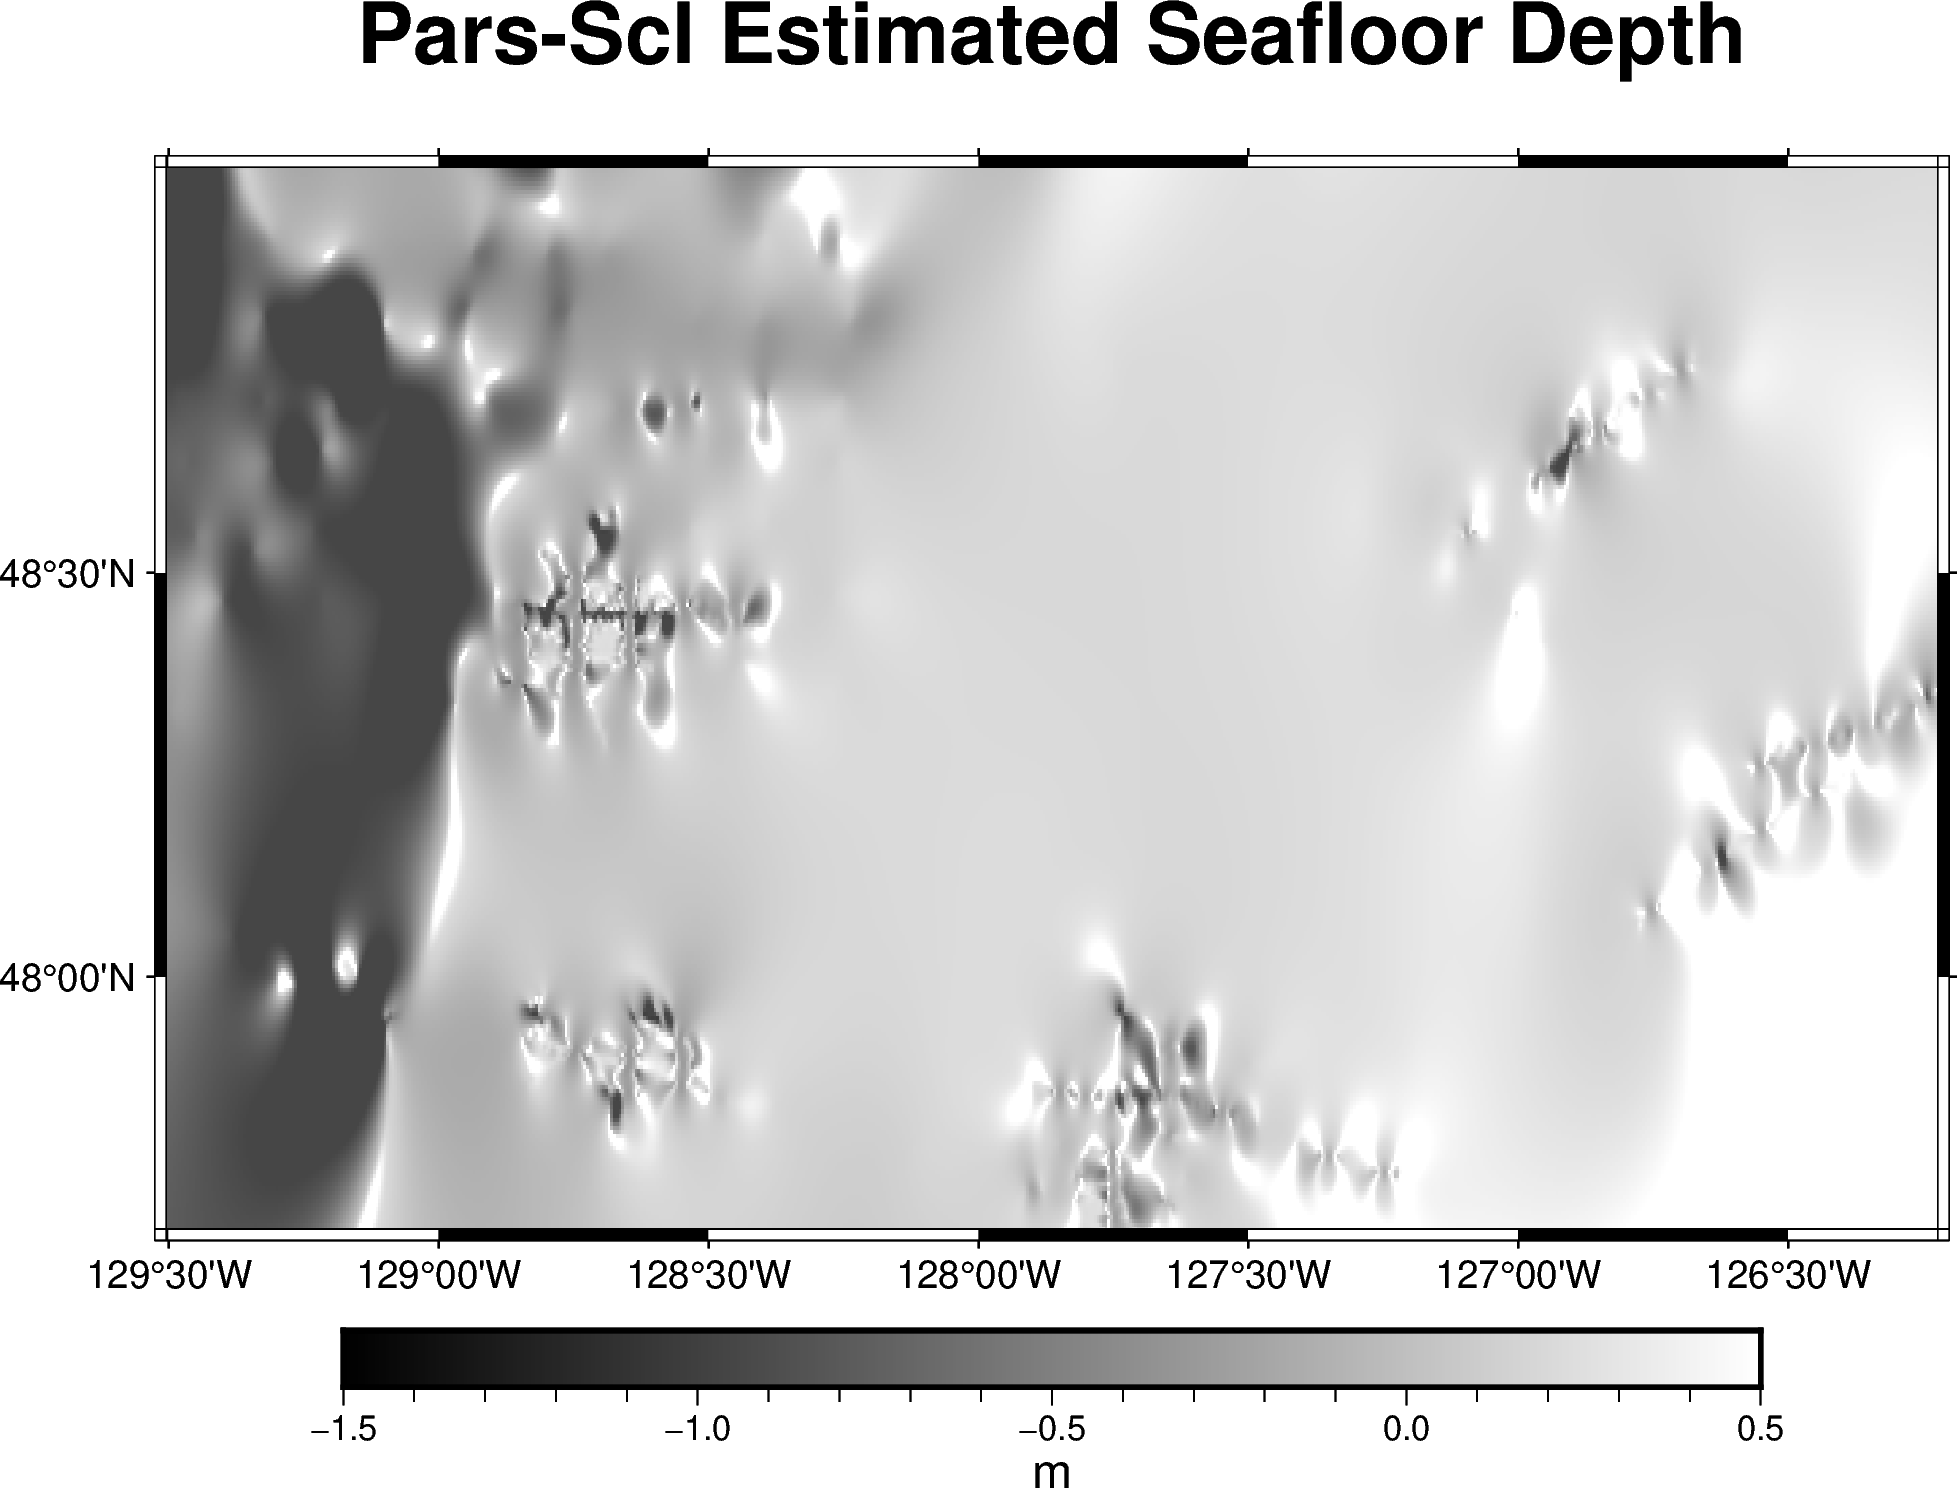

In [50]:
dgrid = pygmt.grdgradient(grid=ps_depth_grid, radiance=[270, 30])

fig = pygmt.Figure()
title = 'Pars-Scl Estimated Seafloor Depth'

pygmt.makecpt(cmap='gmt/gray', series=[-1.5, 0.5, 0.005])
fig.grdimage(grid=dgrid, projection='M15c', frame=('a', f'+t{title}'), cmap=True)

fig.colorbar(cmap=True, frame=['a0.5f0.1', 'x+lm'])  # annotate every x, tick every y
# fig2.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.5p,red')
# fig2.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')

fig.savefig('..\\..\\figures\\seg2\\1test_relief_depth_ps_0.005.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig.show()

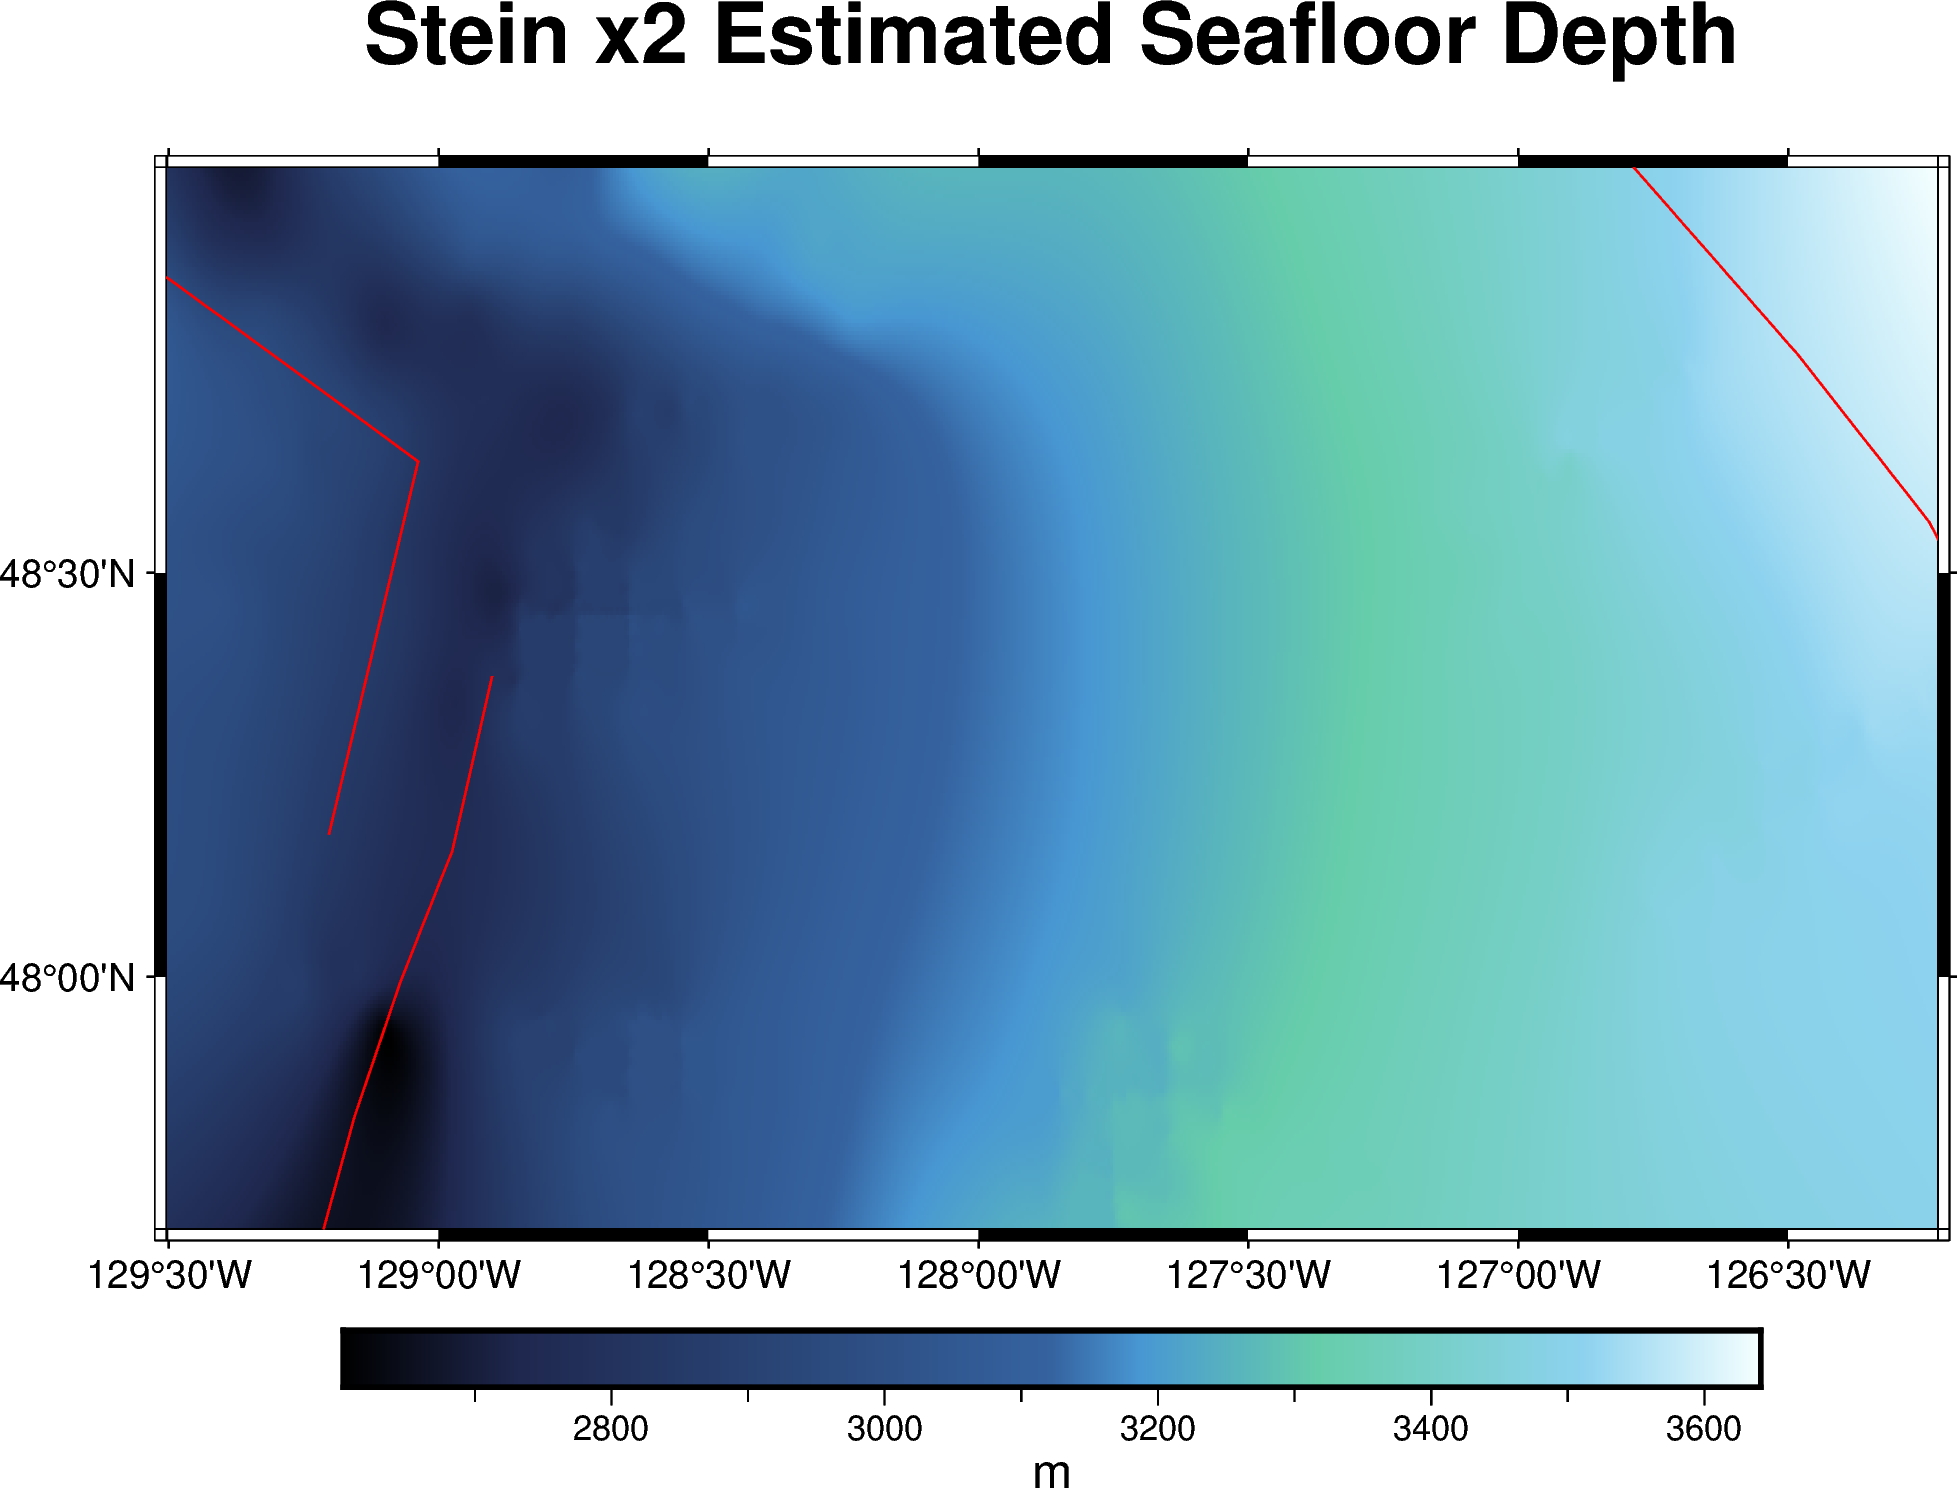

In [51]:
fig3 = pygmt.Figure()
title = 'Stein x2 Estimated Seafloor Depth'

pygmt.makecpt(cmap='bathy', series=[stein_depth_grid.min().values, stein_depth_grid.max().values])

fig3.grdimage(grid=stein_depth_grid, cmap=True, region=region, projection='M15c', frame=['a', f'+t{title}'])
fig3.colorbar(cmap=True, frame=['a200f100', 'x+lm'])  # annotate every x, tick every y
fig3.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.5p,red')
fig3.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')

fig3.savefig('..\\..\\figures\\seg2\\depth_stein_0.005.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig3.show()

In [52]:
diff_depth = stein_depth_grid - ps_depth_grid

# print(diff_depth.head())

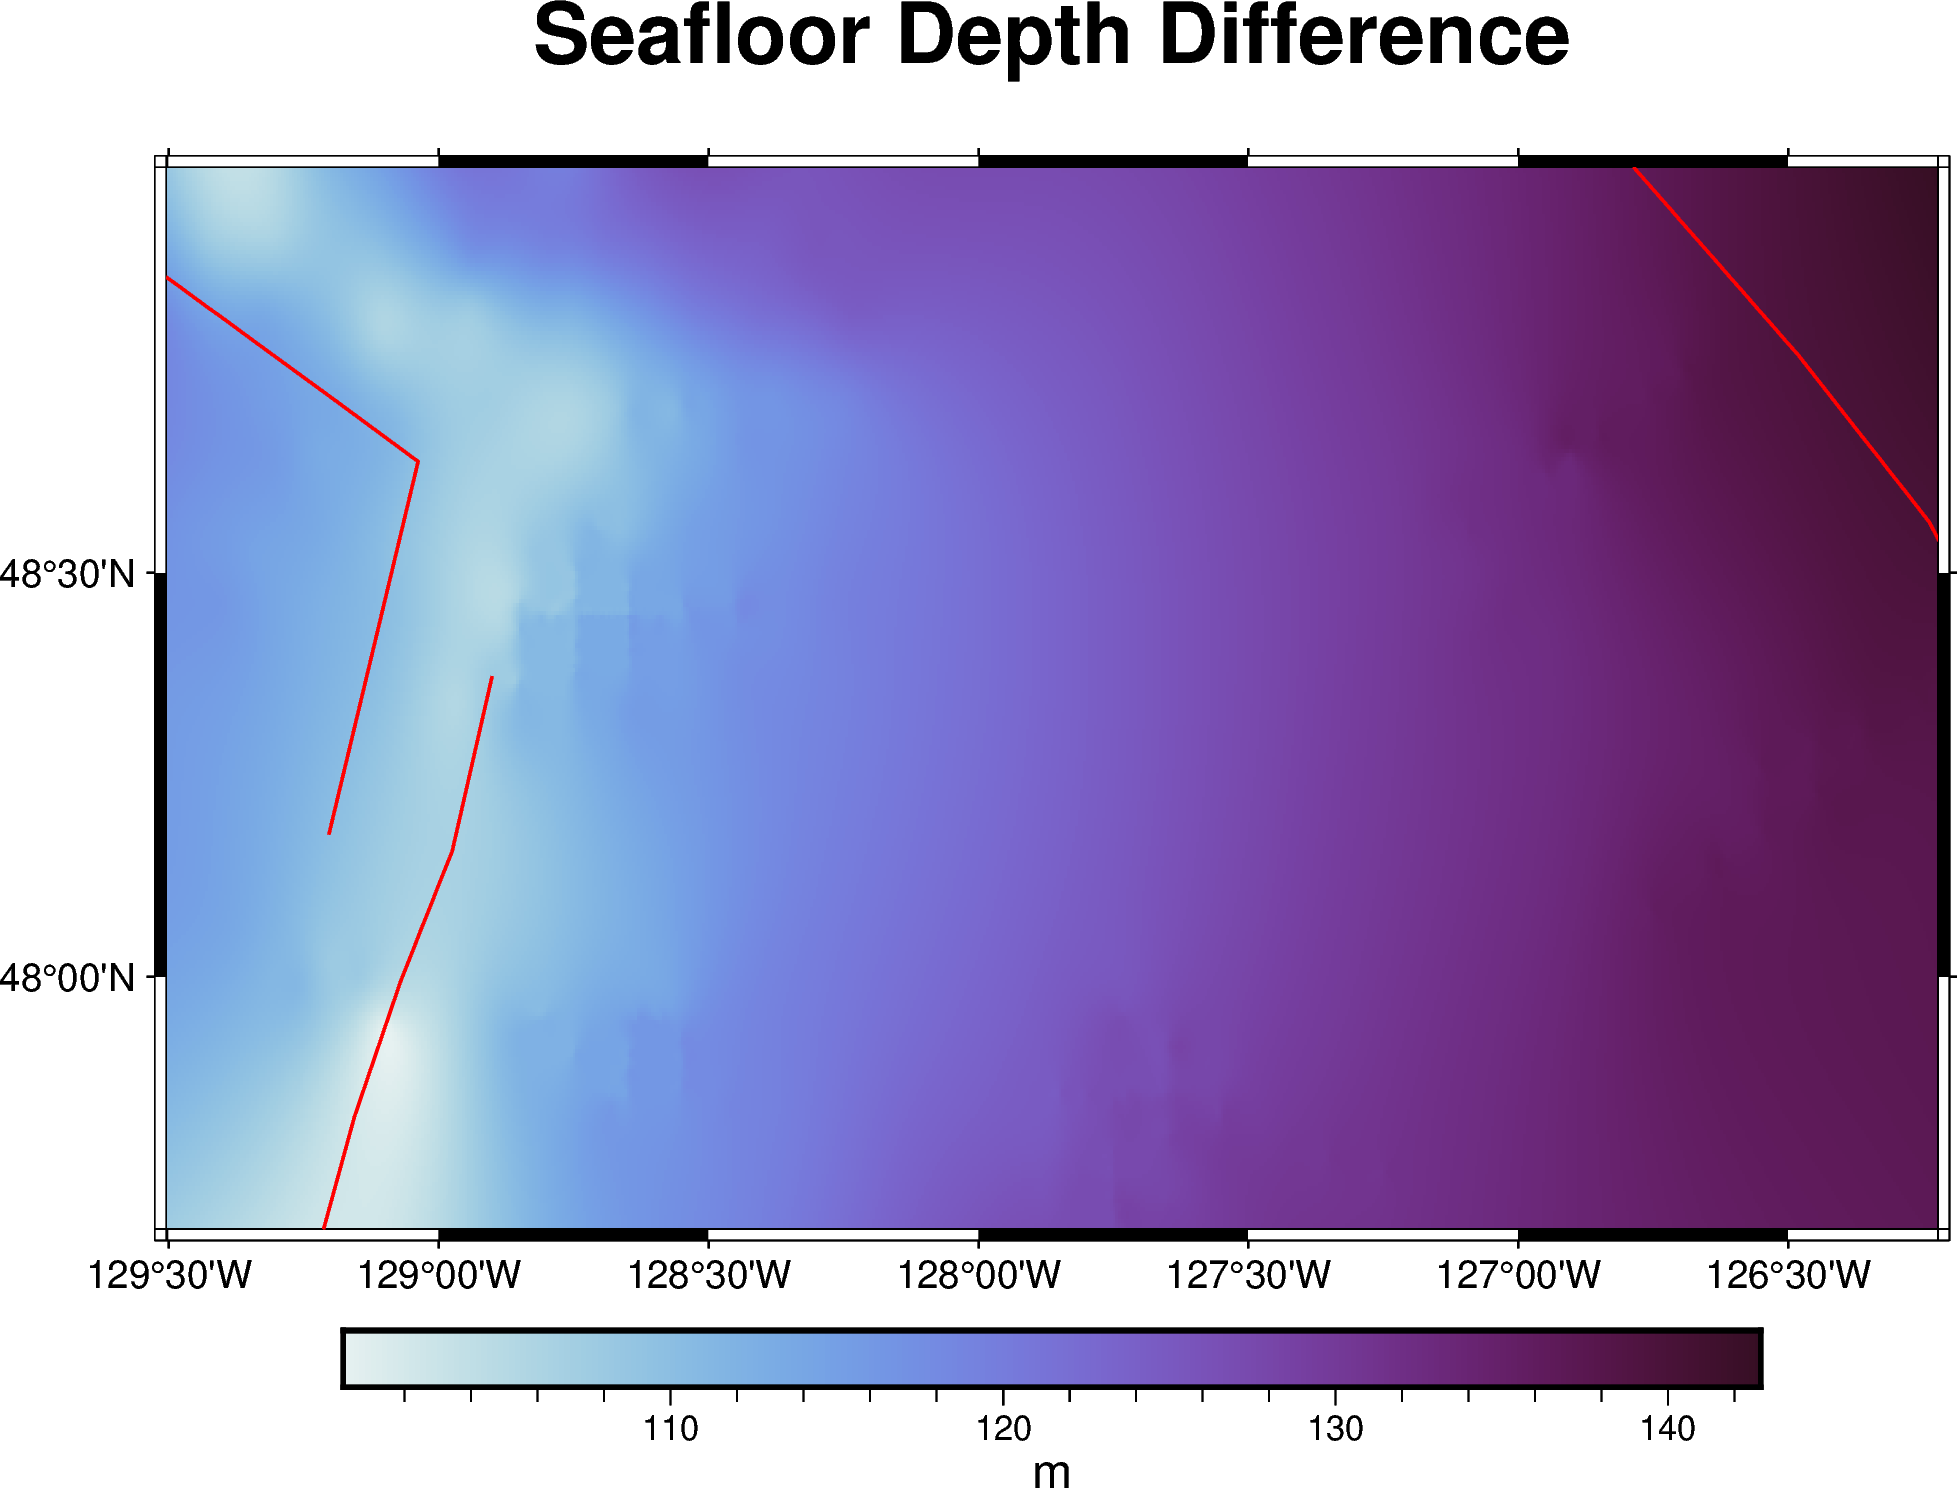

In [70]:
fig4 = pygmt.Figure()
title = 'Seafloor Depth Difference'

pygmt.makecpt(cmap='dense', series=[diff_depth.min().values, diff_depth.max().values])

fig4.grdimage(grid=diff_depth, cmap=True, region=region, projection='M15c', frame=['a', f'+t{title}'])
fig4.colorbar(cmap=True, frame=['a10f2', 'x+lm'])  # annotate every x, tick every y
fig4.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.75p,red')
fig4.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')

fig4.savefig('..\\..\\figures\\seg2\\depth_diff_0.005.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig4.show()

In [59]:
srtm = pd.read_csv('..\\..\\data\\csv_segments\\srtm_seg2_lat_long_z.txt', sep='\\s', header=0, engine='python',
                 names=['lat', 'lon', 'z'])
print(srtm.head())


        lat      lon            z
0  47.07474 -130.125 -2697.497559
1  47.07474 -129.859 -2736.506348
2  47.07474 -129.592 -2698.546631
3  47.07474 -129.325 -2554.697510
4  47.07474 -129.059 -2626.030273


In [60]:
block_reduce = pygmt.blockmedian(x=srtm['lon'], y=srtm['lat'], z=srtm['z'],   # or whatever column you want gridded
    region=region,
    spacing=spacing)

# interpolate onto a continuous grid
srtm_depth_grid = pygmt.surface(data=block_reduce, region=region, spacing=spacing)

print(srtm_depth_grid.head())

blockmedian [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
blockmedian [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
blockmedian (gmtapi_init_grdheader): Please select compatible -R and -I values
surface [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
surface [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
surface (gmtapi_init_grdheader): Please select compatible -R and -I values
surface [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
surface [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
surface (gmtapi_init_grdheader): Please select compatible -R and -I values


<xarray.DataArray 'z' (y: 5, x: 5)> Size: 100B
array([[-2333.2954, -2336.092 , -2338.868 , -2341.622 , -2344.3533],
       [-2333.6846, -2336.4727, -2339.24  , -2341.986 , -2344.7095],
       [-2334.0718, -2336.851 , -2339.61  , -2342.348 , -2345.0635],
       [-2334.4563, -2337.2266, -2339.9773, -2342.707 , -2345.415 ],
       [-2334.8374, -2337.599 , -2340.3413, -2343.0632, -2345.7634]],
      dtype=float32)
Coordinates:
  * y        (y) float64 40B 47.69 47.69 47.7 47.7 47.71
  * x        (x) float64 40B -129.5 -129.5 -129.5 -129.5 -129.5
Attributes:
    Conventions:   CF-1.7
    title:         Data gridded with continuous surface splines in tension
    history:       gmt surface @GMTAPI@-S-I-D-V-T-N-000000 -G@GMTAPI@-S-O-G-G...
    description:   
    actual_range:  [nan nan]
    long_name:     z


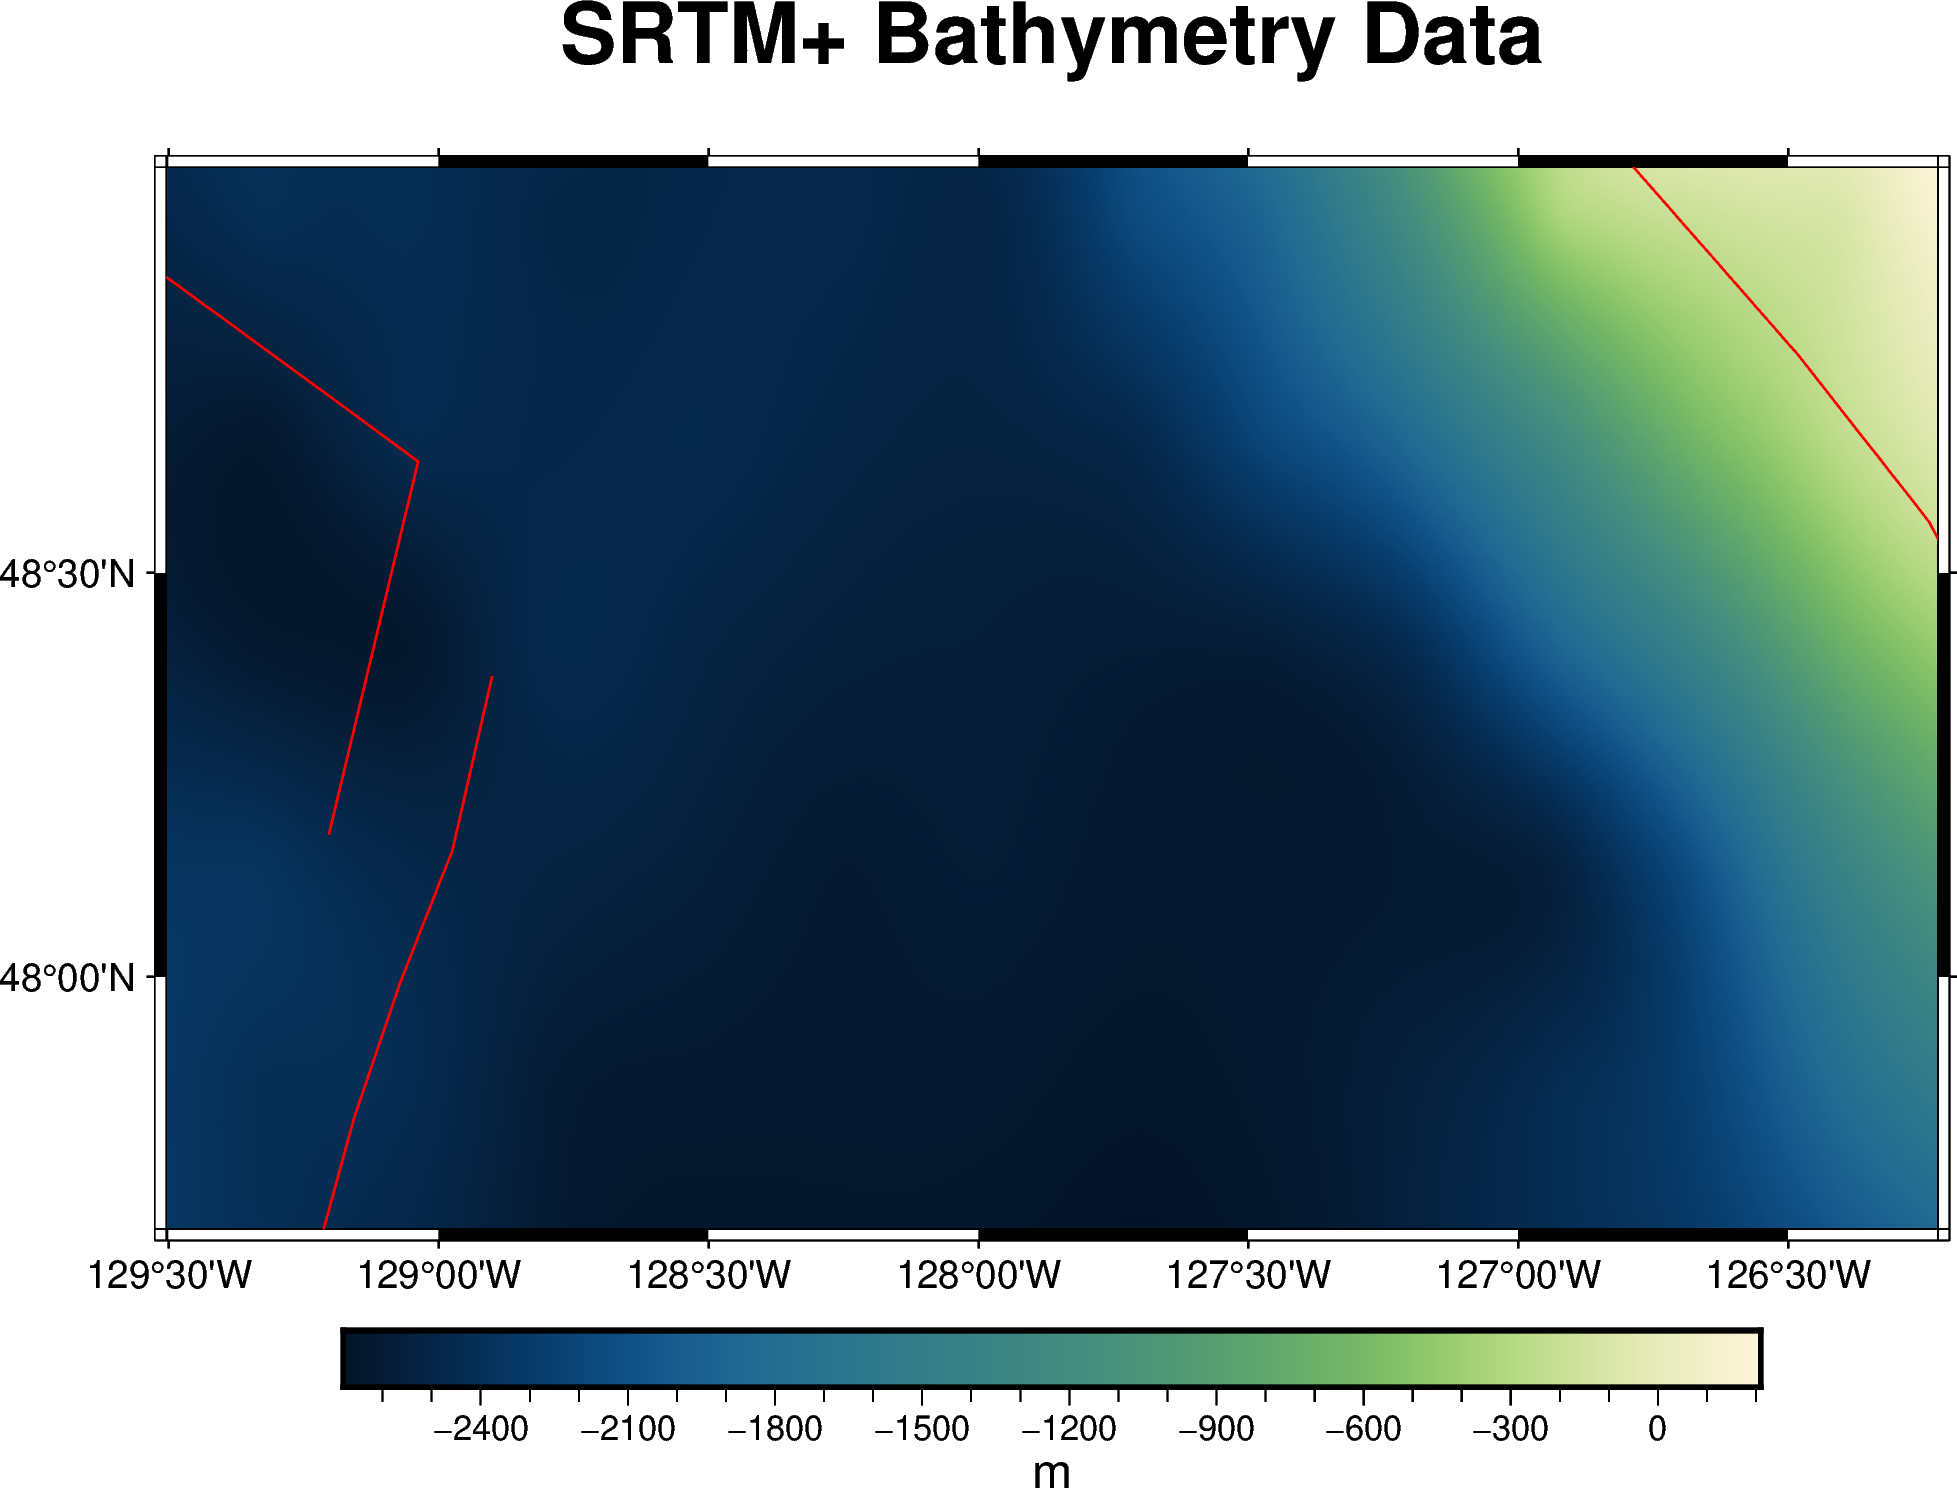

In [78]:
fig5 = pygmt.Figure()
title = 'SRTM+ Bathymetry Data'

pygmt.makecpt(cmap='navia', series=[srtm_depth_grid.min().values, srtm_depth_grid.max().values])

fig5.grdimage(grid=srtm_depth_grid, cmap=True, region=region, projection='M15c', frame=['a', f'+t{title}'])
fig5.colorbar(cmap=True, frame=['a300f100', 'x+lm'])  # annotate every x, tick every y
fig5.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.5p,red')
fig5.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')

fig5.savefig('..\\..\\figures\\seg2\\depth_srtm_0.005.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig5.show()